In [10]:
using LinearAlgebra
using Plots
gr()
Plots.GRBackend()
filename = ""

include("Optimisation.jl")
include("Parameterization.jl")
include("RaySolver.jl")
include("PlotRays.jl")

In [11]:
controlx = [-1.5 -1.2 -0.7 -0.3 0. 0.3 0.7 1. 1.5]
controly = [0. 0.1 0.3 0.5 0. 0.5 0.4 0.1 0.] .+ 1.
control = vcat(controlx, controly)
control0 = control

2×9 Matrix{Float64}:
 -1.5  -1.2  -0.7  -0.3  0.0  0.3  0.7  1.0  1.5
  1.0   1.1   1.3   1.5  1.0  1.5  1.4  1.1  1.0

In [12]:
n = size(control)[2]
fixedcontrolpoint = control[:, div(n+1,2)]

2-element Vector{Float64}:
 0.0
 1.0

In [13]:
#Fonction coût écart à un point
# Jeu de rayons parallèles en entrée
Nray = 1000
FOV = 15 # en degrés
FOV = FOV * pi / 180.
source0 = (Ray([0., 0. ], pi / 2. - FOV + 2 * FOV * i / Nray  ) for i in 0:Nray)

Base.Generator{UnitRange{Int64}, var"#49#50"}(var"#49#50"(), 0:1000)

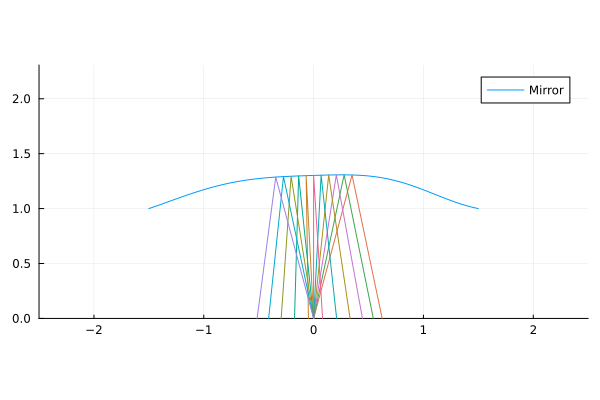

In [14]:
points = bezier(control, 0.)
for i in 1:100 
    points = hcat( points, bezier(control,i / 100)) 
end
#n = size(control)[2]
xlim = ( - maximum( -1. .*points[1,:] ) -1. , maximum( points[1,:] ) +1. )
ylim =  ( - maximum( -1. .*points[2,:] ) -1. , maximum( points[2,:] )  + 1. )
plt = plot(points[1,:],points[2,:], xlims = xlim, ylims =  ylim, aspect_ratio=:equal, label = "Mirror")
source4plot = (Ray([0., 0. ], pi / 2. - FOV + 2 * FOV * i / 10  ) for i in 0:10)
for ray in source4plot
    plot!(ray)
end
savefig("rays_verif_dir.png")
display(plt)

In [55]:
#Fonction coût
function cost0(control::Matrix{Float64})::Float64
    return  sum(  (cos(projectionplanfocal(billiard(control,ray) ).angle) - sqrt(2.) / 2.)^2 for ray in source0) / length(source0)
end
cost0(control)

1.7568124940101

In [56]:
# Differentiel en x de la foinction cout sur le plan focal
function diffj0x(ray::Ray)::Vector{Float64}
    return [0., 0.]
end

# Differentiel en xi de la foinction cout sur le plan focal
function diffj0xi(ray::Ray)::Vector{Float64}
    return 2. .* [cos(ray.angle) - sqrt(2.)/2., 0. ]
end

# Differentiel en x de la foinction cout sur le miroir
function jtildex(ray::Ray)::Vector{Float64}
    rayf = projectionplanfocal(ray)
    return diffprojectionplanfocalx(ray, diffj0x(rayf), diffj0xi(rayf))
end

# Differentiel en xi de la foinction cout sur le miroir
function jtildexi(ray::Ray)::Vector{Float64}
    rayf = projectionplanfocal(ray)
    return diffprojectionplanfocalxi(ray, diffj0x(rayf), diffj0xi(rayf))
end


jtildexi (generic function with 1 method)

In [57]:
function cross2d(vec1::Vector{Float64}, vec2::Vector{Float64})::Real
    return vec1[1]* vec2[2] - vec1[2]* vec2[1] 
end
cross2d([0.,1.], [1.,0.])

-1.0

In [58]:
#### fusionner jtilde
### fusionner projection focal (matrice par bloc ? utiliser strcture de julia)
function gradientj0(control::Matrix{Float64})::Matrix{Float64}
    n::Int64 = size(control)[2] - 1  # Degree of the Béziers curve  
    gradient::Matrix{Float64} = zeros(2,n+1)
    for ray in source0
        # on projette sur le miroir et on récupère le $t$ de param
        t::Float64 = intersectionLine(control, ray) 
        dic = geometricquantities(control, t)
        theta = ray.angle
        #prendre un dangle et une normale sortante et renvoie l'angle correspondant au rayon réfléchi
        sdot = dic["normal"][1] * cos(theta) + dic["normal"][2] * sin(theta)
        thetaf = atan( sin(theta) - 2. * sdot * dic["normal"][2], cos(theta) - 2. * sdot * dic["normal"][1] )
        #on calcule les termes de la dérivée de formes
        sderterm = shapederivativeterms(control, t) #termes de la dérivée de formes
        rayr = Ray(dic["point"], thetaf)
        djx = jtildex(rayr)
        djxi = jtildexi(rayr)
        gradient += dot(dic["normal"], djx ) .*  sderterm["thetan"]
        gradient +=  ( sderterm["thetanprime"] * cross2d(dic["normal"], dic["utangent"]) .-  sderterm["thetan"] .* (dic["curvature"] * cross2d(dic["normal"], [cos(thetaf), sin(thetaf)]) / dot([cos(thetaf), sin(thetaf) ], dic["normal"])   ) ) * cross2d(djxi, [cos(thetaf), sin(thetaf)])
    end
    return 2. * gradient ./ length(source0)
end

#elle modifie la fonction initiale. Il faudrait mettre un !
function projection(control::Matrix{Float64})::Matrix{Float64}
    n::Int64 = size(control)[2]
    control[: , div(n+1,2)] = fixedcontrolpoint
    return control
end


projection (generic function with 1 method)

In [59]:
iter=Vector{Float64}(undef, 0)
cost=Vector{Float64}(undef, 0)
control = OptimGradient(cost0, gradientj0, control, 0.1, norm, norm, projection, true, 2000)

Number of total iterations exceeded
The final value of the gradient norm (distance 1) is : 0.0010034524202478033
The final value of the cost is : 5.7307371494313744e-5


2×9 Matrix{Float64}:
 -1.42326   -0.97806   -0.552318  -0.429202  …  0.937103  1.1016   1.51183
  0.821617   0.541049   0.767716   1.51391      1.62122   1.34662  1.09158

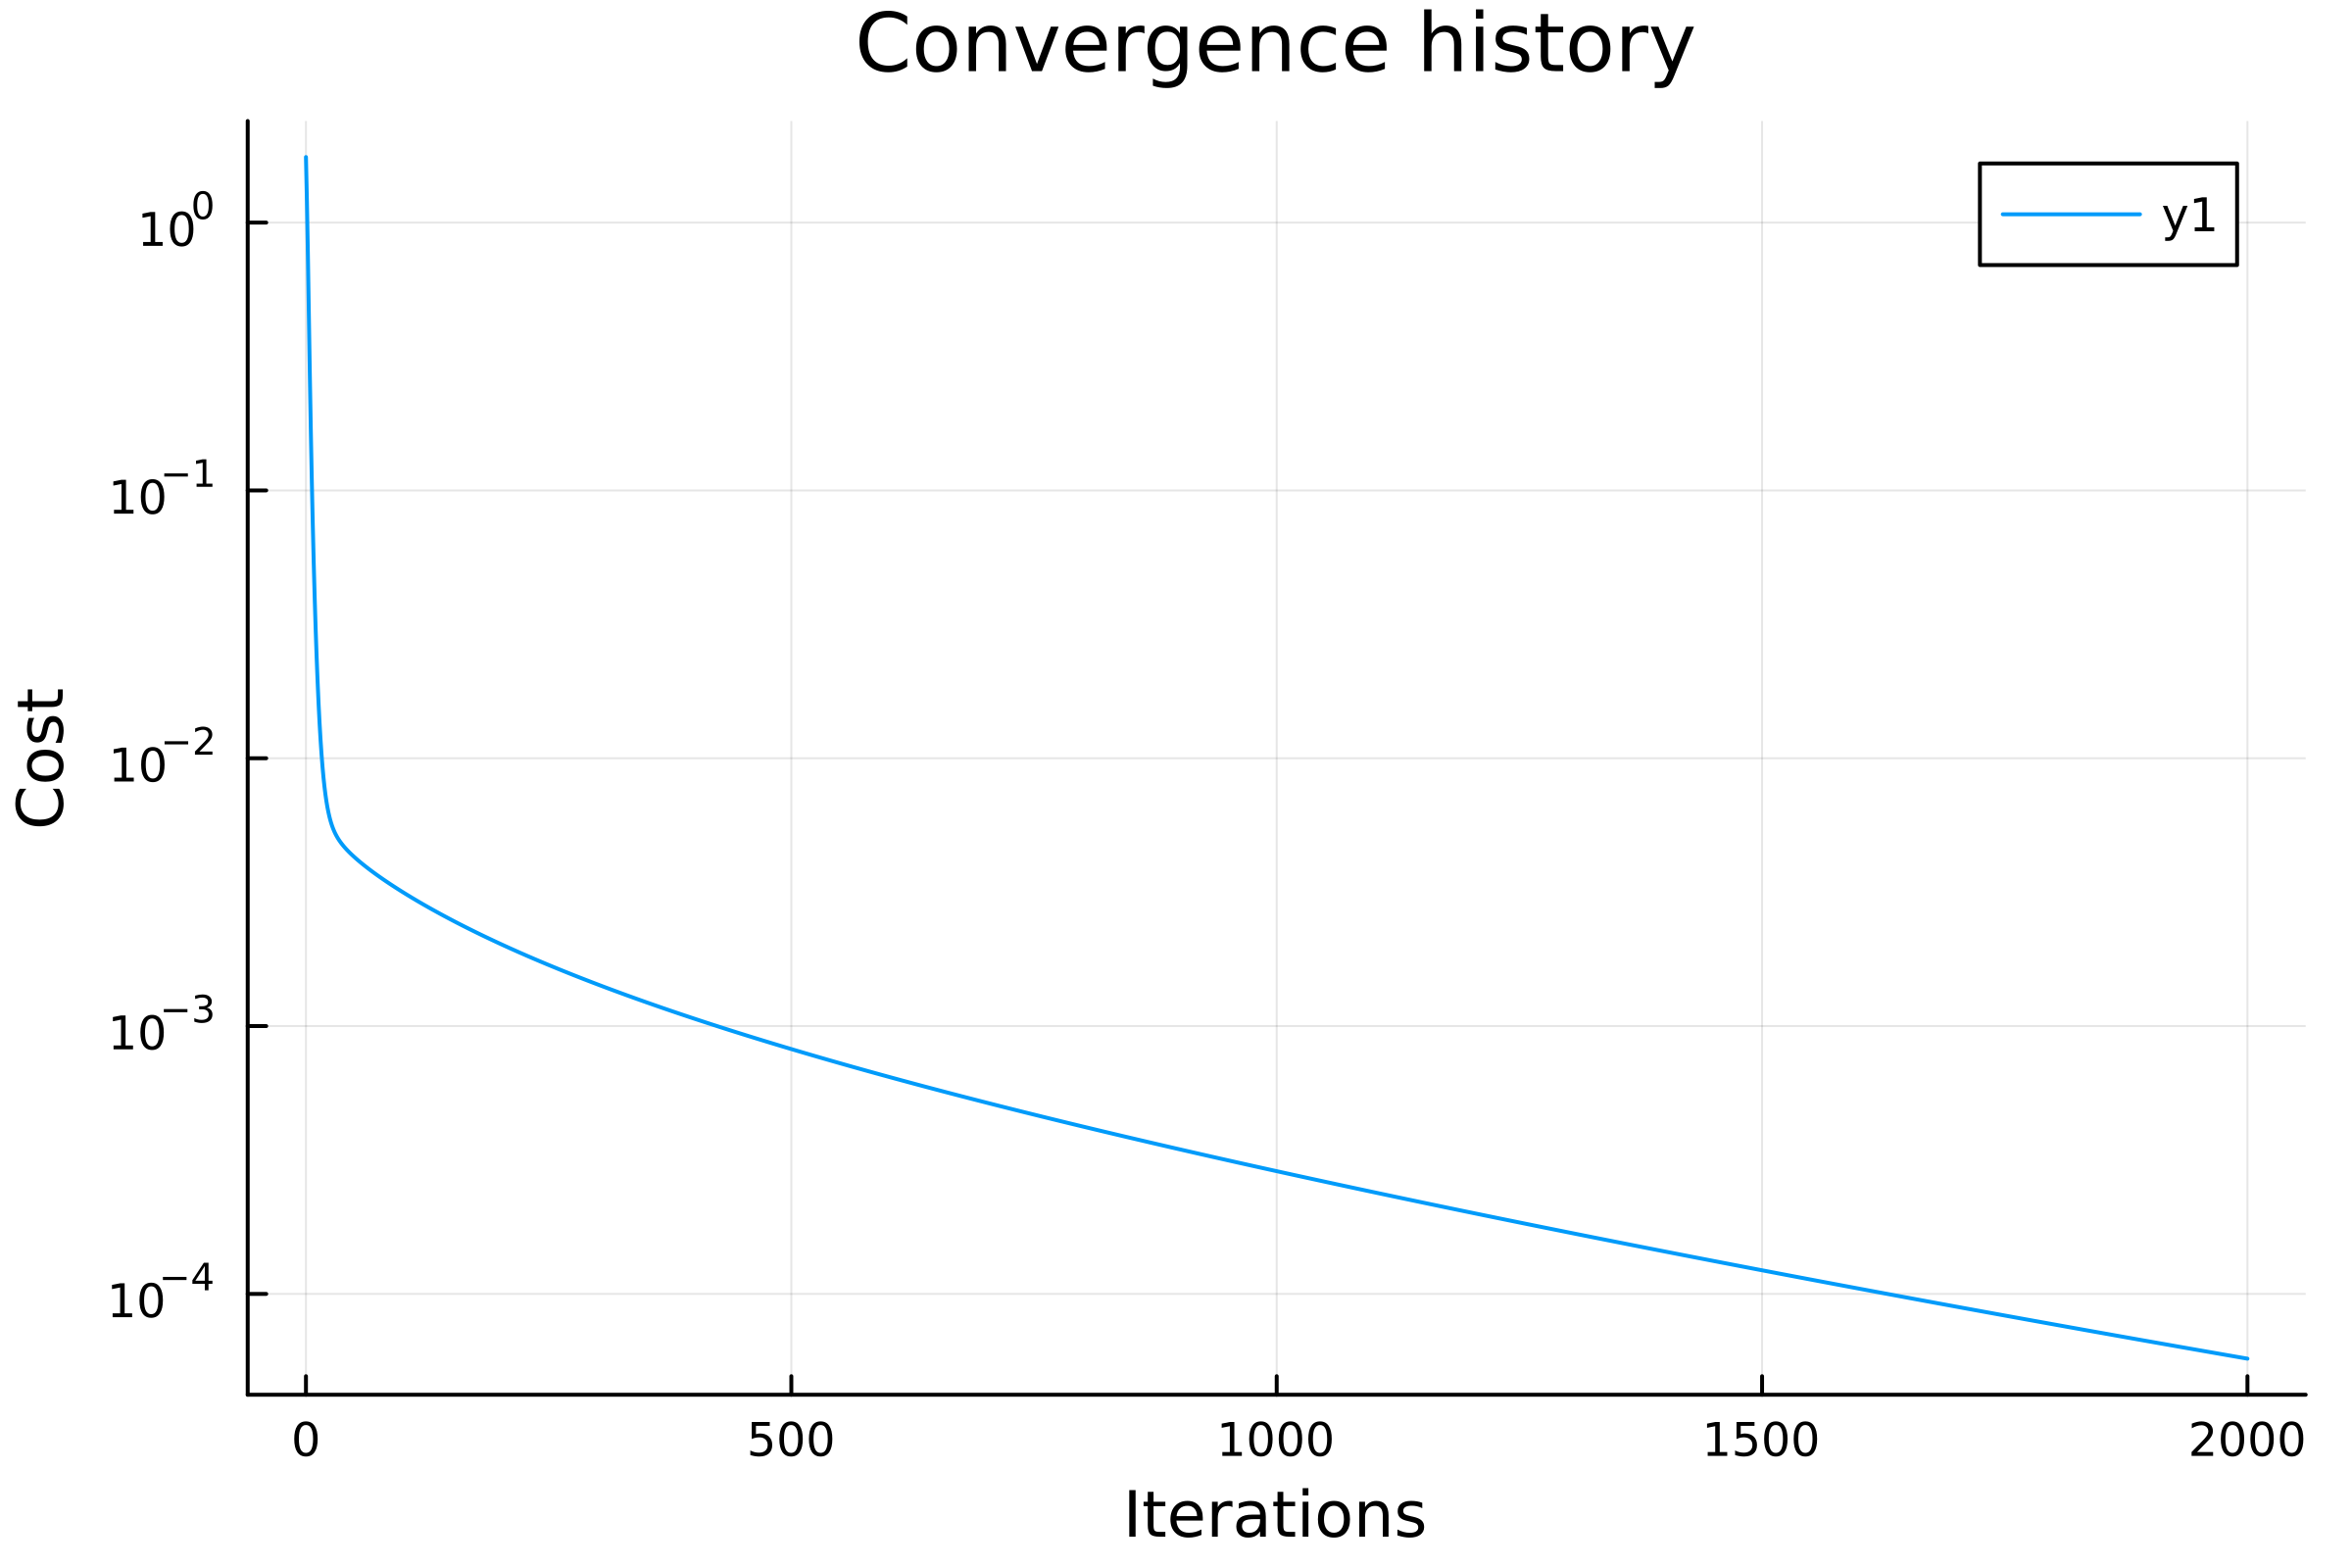

In [61]:
plt = plot(iter,cost,title= "Convergence history", xlabel = "Iterations", ylabel = "Cost", dpi = 400, yaxis = :log)
savefig("convergence_history_direction.png")
plot(plt)

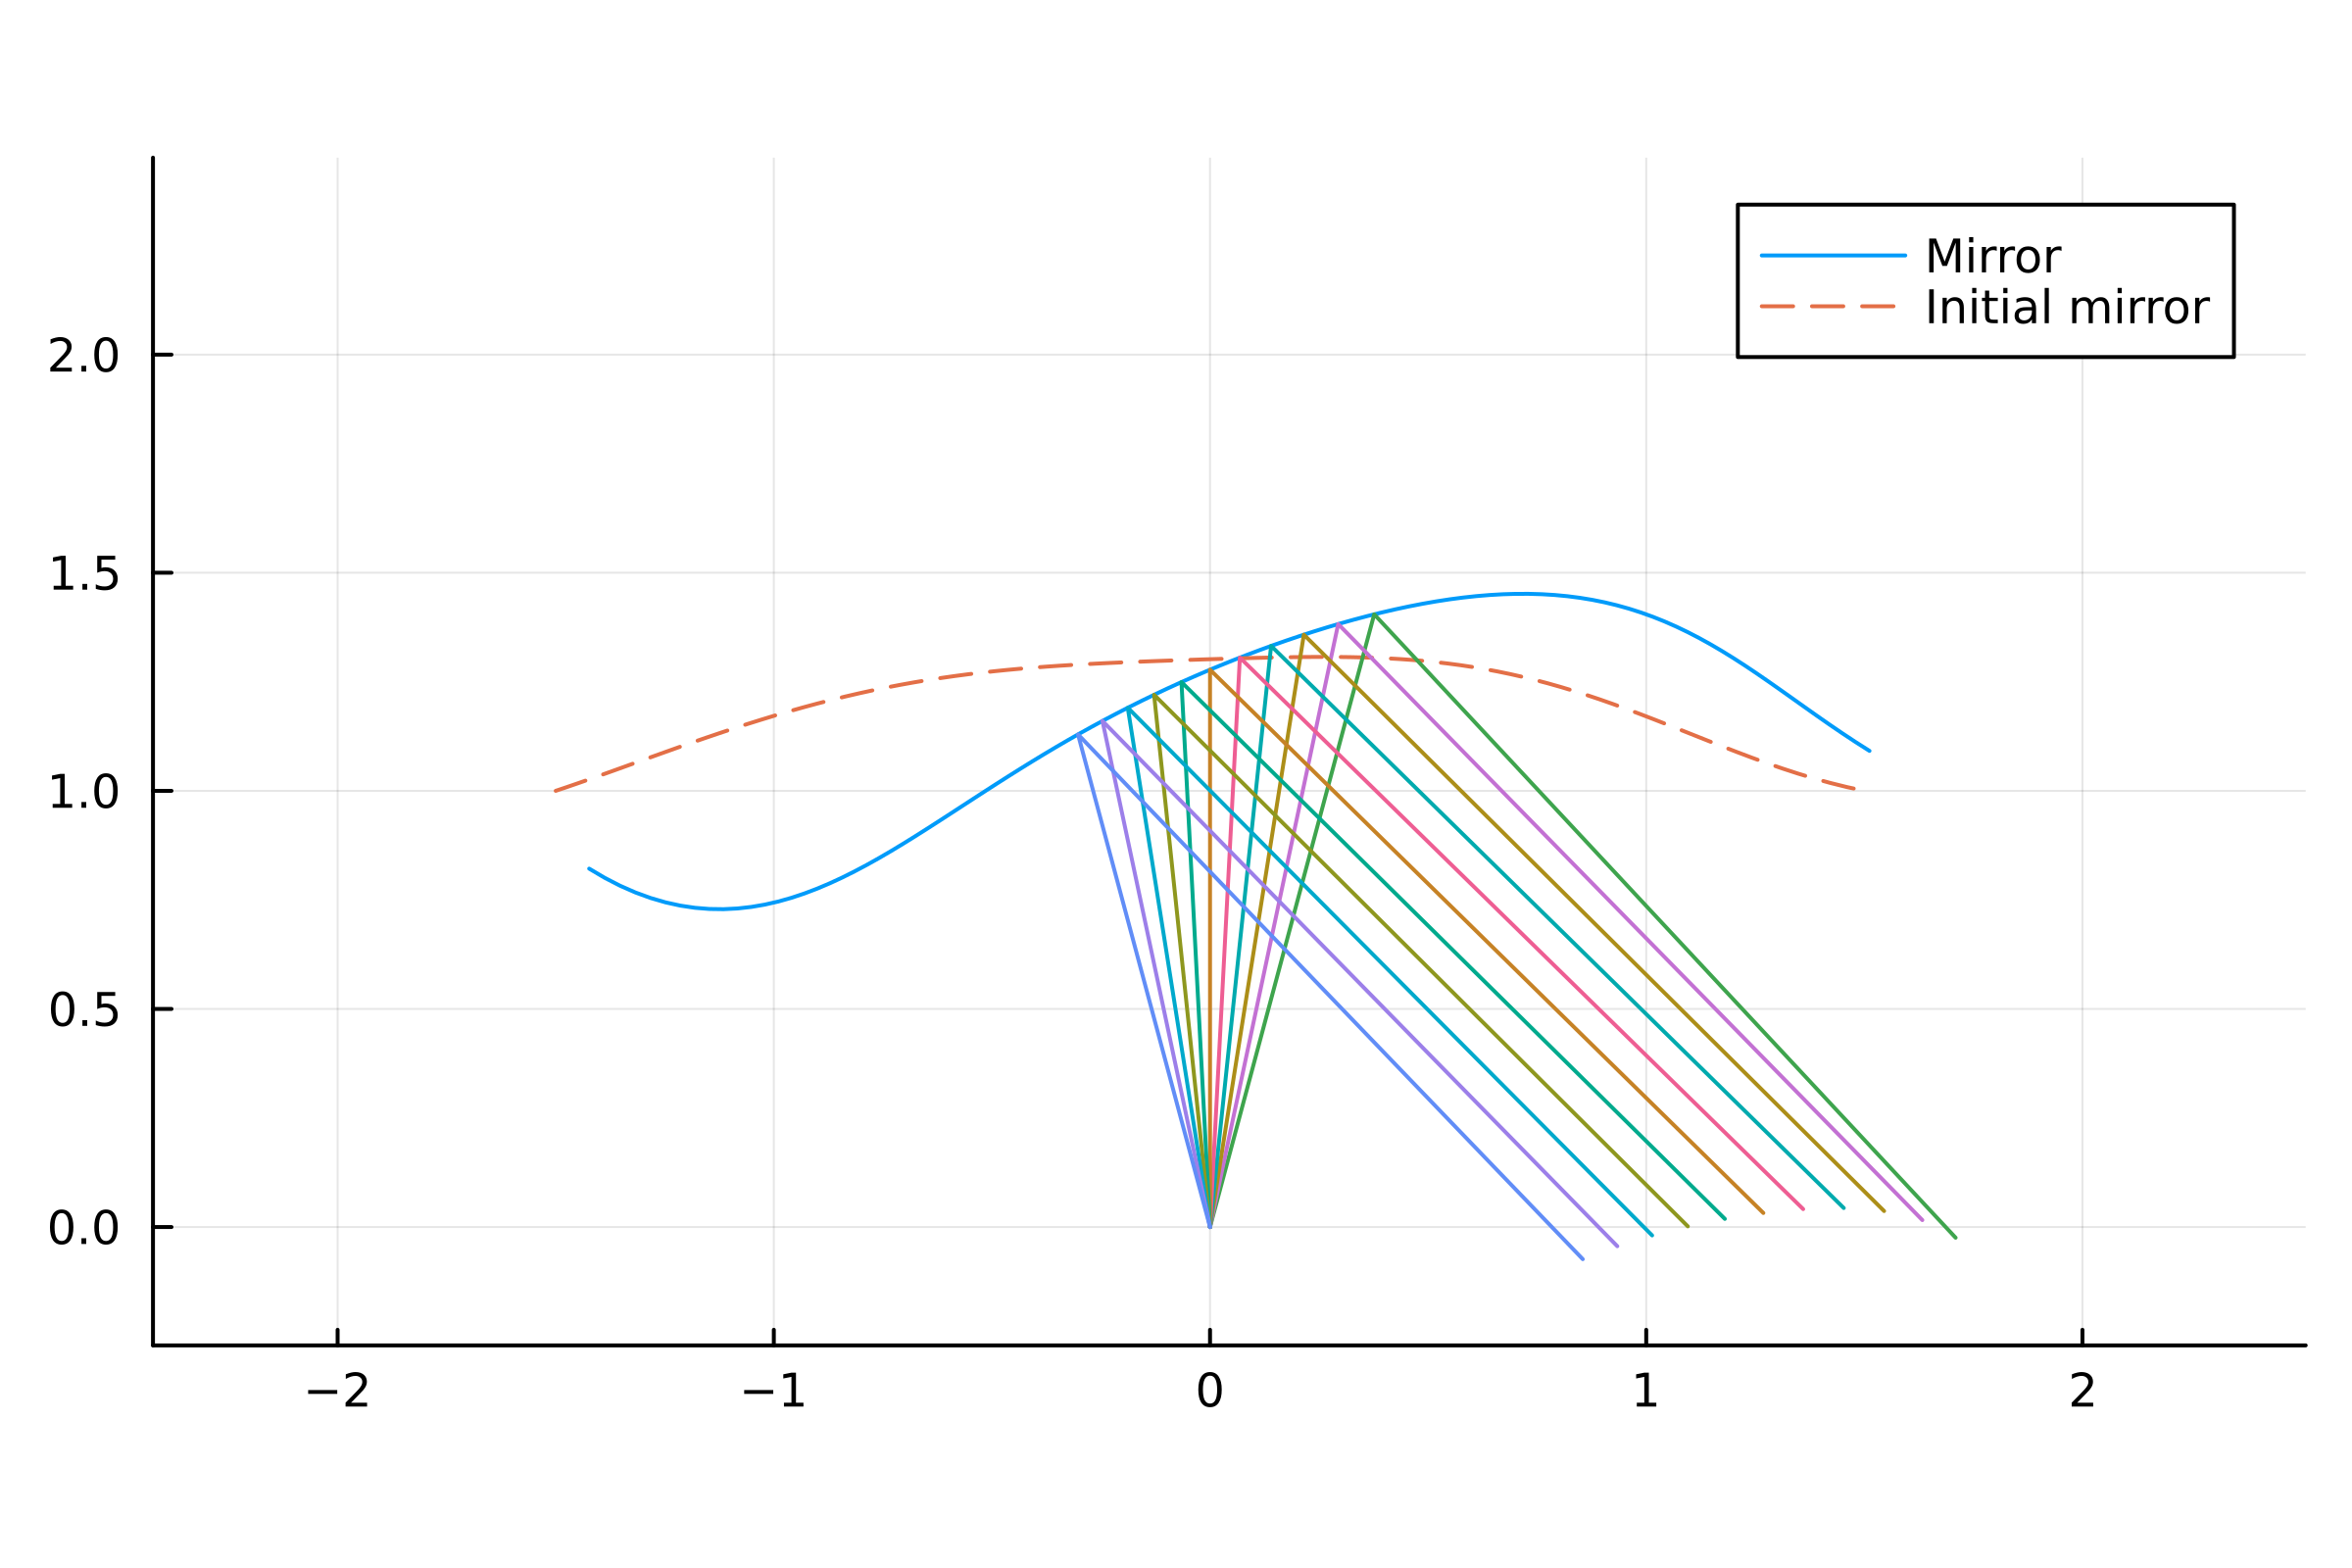

In [66]:
points = bezier(control, 0.)
points0 = bezier(control0, 0.)
for i in 1:100 
    points = hcat( points, bezier(control,i / 100)) 
    points0 = hcat( points0, bezier(control0,i / 100)) 
end
#n = size(control)[2]
xlim = ( - maximum( -1. .*points[1,:] ) -1. , maximum( points[1,:] ) +1. )
ylim =  ( - maximum( -1. .*points[2,:] ) -1. , maximum( points[2,:] )  + 1. )
plt = plot(points[1,:],points[2,:], xlims = xlim, ylims =  ylim, aspect_ratio=:equal, label = "Mirror", dpi = 400)
plot!(points0[1,:],points0[2,:], xlims = xlim, ylims =  ylim, aspect_ratio=:equal, label = "Initial mirror", linestyle=:dash, dpi = 400)
for ray in source4plot
    plot!(ray)
end
savefig("dir_optim_final_rays.png")
display(plt)

In [67]:
points = bezier(control, 0.)
for i in 1:100 
    points = hcat( points, bezier(control,i / 100)) 
end
xlim = ( - maximum( -1. .*points[1,:] ) -1. , maximum( points[1,:] ) +1. )
ylim =  ( - maximum( -1. .*points[2,:] ) -1. , maximum( points[2,:] )  + 1. )
plt = plot(points[1,:],points[2,:], xlims = xlim, ylims =  ylim, aspect_ratio=:equal, label = "Mirror", dpi = 400)

angles = zeros(length(source0))
for (k,ray) in enumerate(source0)
    angles[k] = 180 * billiard(control,ray).angle / pi
end
histogram(angles,bins = 50, label = "Histogram of rays", xlabel = "Reflected angle (degrees)")
savefig("dir_optim_final_rays_histo.png")

"/Users/lucagorini/Desktop/working_notes/RayTracingSolver_V2_2D/dir_optim_final_rays_histo.png"

In [495]:
# config initiale (avec rayons) 
# config initiale + optimisée sur le même miroir
# histogramme
# courbe de convergence
